# Addition experiment
## create two data manifolds X1, X2, each of dimension N * d and tail exponents alpha_Xi
## calculate PP(Xi) and actual alpha_Xi
## define X12 = X1 + X2
## calculate PP(X12) and actual alpha_X12
### PatnaikPearson_addition_20260507.ipynb



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [4]:
import PatnaikPearson as pp
import cupy

## Experiment One : fix N and d. Choose alpha_Xi randomly
## N = 1000, d = 500

In [8]:
num_iterations = 100

min_alpha = 0.1
max_alpha = 4.0
scale_factor = max_alpha - min_alpha

this_N = 1000
this_d = 500

alpha_X1_vals = np.zeros(num_iterations)
alpha_X2_vals = np.zeros(num_iterations)
actual_alpha_X1_vals = np.zeros(num_iterations)
actual_alpha_X2_vals = np.zeros(num_iterations)
actual_alpha_X1plusX2_vals = np.zeros(num_iterations)
estimate_alpha_X1plusX2_vals = np.zeros(num_iterations)
min_alpha_X1_alpha_X2_vals = np.zeros(num_iterations)
max_alpha_X1_alpha_X2_vals = np.zeros(num_iterations)
pp_dim_X1_vals = np.zeros(num_iterations)
pp_dim_X2_vals = np.zeros(num_iterations)
pp_dim_X1plusX2_vals = np.zeros(num_iterations)
nu_over_d_X1_vals = np.zeros(num_iterations)
nu_over_d_X2_vals = np.zeros(num_iterations)
nu_over_d_X1plusX2_vals = np.zeros(num_iterations)
estimate_nu_over_d_X1plusX2_vals = np.zeros(num_iterations)
min_nu_over_d_X1_nu_over_d_X2_vals = np.zeros(num_iterations)
max_nu_over_d_X1_nu_over_d_X2_vals = np.zeros(num_iterations)


for i in range(num_iterations):
    this_alpha_X1 = min_alpha + scale_factor * np.random.uniform(0,1)
    this_alpha_X2 = min_alpha + scale_factor * np.random.uniform(0,1)

    results_dict = pp.addition_experiment(this_N, this_d, this_alpha_X1, this_alpha_X2, use_svd = True)

    actual_alpha_X1 = results_dict["actual_alpha_X1"]
    actual_alpha_X2 = results_dict["actual_alpha_X2"]
    actual_alpha_X1plusX2 = results_dict["actual_alpha_X1plusX2"]
    pp_dim_X1 = results_dict["pp_dim_X1"] 
    pp_dim_X2 = results_dict["pp_dim_X2"]
    pp_dim_X1plusX2 = results_dict["pp_dim_X1plusX2"] 
    nu_over_d_X1 = results_dict["nu_over_d_X1"]
    nu_over_d_X2 = results_dict["nu_over_d_X2"] 
    nu_over_d_X1plusX2 = results_dict["nu_over_d_X1plusX2"] 
    
    alpha_X1_vals[i] = this_alpha_X1
    alpha_X2_vals[i] = this_alpha_X2
    actual_alpha_X1_vals[i] = actual_alpha_X1
    actual_alpha_X2_vals[i] = actual_alpha_X2
    actual_alpha_X1plusX2_vals[i] = actual_alpha_X1plusX2
    estimate_alpha_X1plusX2 = min(actual_alpha_X1, actual_alpha_X2)
    estimate_alpha_X1plusX2_vals[i] = estimate_alpha_X1plusX2
    pp_dim_X1_vals[i] = pp_dim_X1
    pp_dim_X2_vals[i] = pp_dim_X2
    pp_dim_X1plusX2_vals[i] = pp_dim_X1plusX2
    nu_over_d_X1_vals[i] = nu_over_d_X1
    nu_over_d_X2_vals[i] = nu_over_d_X2
    nu_over_d_X1plusX2_vals[i] = nu_over_d_X1plusX2
    estimate_nu_over_d_X1plusX2 = min(nu_over_d_X1, nu_over_d_X2)
    min_alpha_X1_alpha_X2_vals[i] = min(actual_alpha_X1, actual_alpha_X2)
    max_alpha_X1_alpha_X2_vals[i] = max(actual_alpha_X1, actual_alpha_X2)
    estimate_nu_over_d_X1plusX2_vals[i] = estimate_nu_over_d_X1plusX2
    min_nu_over_d_X1_nu_over_d_X2_vals[i] = min(nu_over_d_X1, nu_over_d_X2)
    max_nu_over_d_X1_nu_over_d_X2_vals[i] = max(nu_over_d_X1, nu_over_d_X2)
    print(i, actual_alpha_X1, actual_alpha_X2, actual_alpha_X1plusX2, estimate_alpha_X1plusX2)
    print(i, nu_over_d_X1plusX2, estimate_nu_over_d_X1plusX2)

using pareto
[1.00333715 1.00669215 1.01006513 1.01345623 1.01686558]
running on GPU
using pareto
[1.00090622 1.00181507 1.00272658 1.00364074 1.00455759]
running on GPU
0 0.5507206860676711 1.9377404469562503 0.5513812602345242 0.5507206860676711
0 0.007836676176244645 0.007809190468138668
using pareto
[1.0014775  1.00296016 1.00444798 1.00594102 1.00743928]
running on GPU
using pareto
[1.00102999 1.00206311 1.00309937 1.00413878 1.00518137]
running on GPU
1 1.242243311741651 1.7442667950770683 1.3189589823541814 1.242243311741651
1 0.22472258583629598 0.1827788949586852
using pareto
[1.00149468 1.00299459 1.00449977 1.00601023 1.00752602]
running on GPU
using pareto
[1.01574744 1.03177514 1.04808866 1.06469369 1.08159603]
running on GPU
2 1.2261768084232747 0.29443261032944273 0.2944326103294429 0.29443261032944273
2 0.002017471680645697 0.002017471680645695
using pareto
[1.00050552 1.0010123  1.00152036 1.0020297  1.00254033]
running on GPU
using pareto
[1.00099497 1.00199292 1.0029

[]

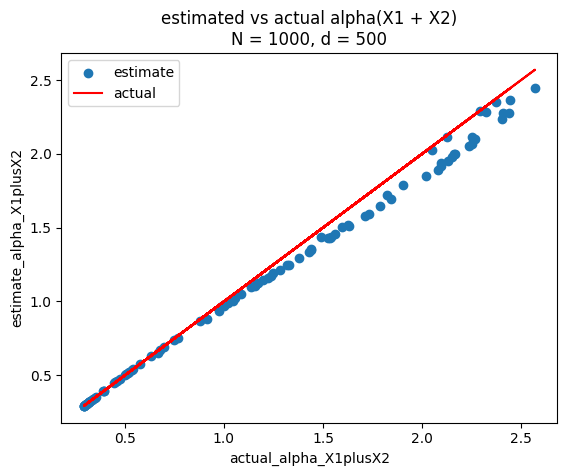

In [6]:
this_title = "estimated vs actual alpha(X1 + X2)\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.scatter(actual_alpha_X1plusX2_vals, estimate_alpha_X1plusX2_vals, label="estimate")
plt.plot(actual_alpha_X1plusX2_vals, actual_alpha_X1plusX2_vals, color="red", label="actual")
plt.xlabel("actual_alpha_X1plusX2")
plt.ylabel("estimate_alpha_X1plusX2")
plt.legend()
plt.title(this_title)
#plt.savefig('alpha_X1_plus_X2.pdf', dpi=300, bbox_inches='tight')
plt.plot()

[]

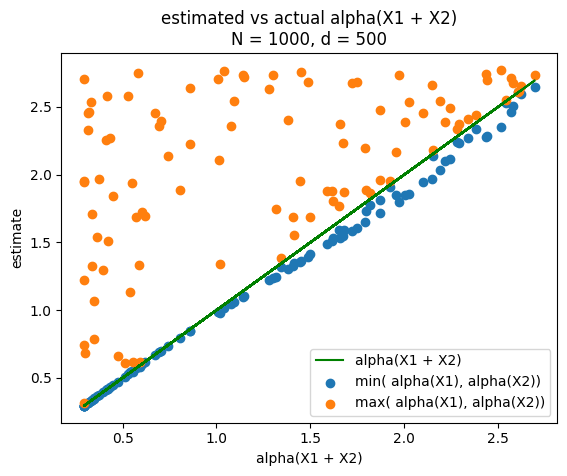

In [13]:
this_title = "estimated vs actual alpha(X1 + X2)\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(actual_alpha_X1plusX2_vals, actual_alpha_X1plusX2_vals, color="green", label="alpha(X1 + X2)")
plt.scatter(actual_alpha_X1plusX2_vals, min_alpha_X1_alpha_X2_vals, label="min( alpha(X1), alpha(X2))")
plt.scatter(actual_alpha_X1plusX2_vals, max_alpha_X1_alpha_X2_vals, label="max( alpha(X1), alpha(X2))")
#plt.plot(actual_alpha_X1plusX2_vals, actual_alpha_X1plusX2_vals, color="red", label="actual")
plt.xlabel("alpha(X1 + X2)")
plt.ylabel("estimate")
plt.legend()
plt.title(this_title)
plt.savefig('alpha_X1_plus_X2_min_max.pdf', dpi=300, bbox_inches='tight')
plt.plot()

[]

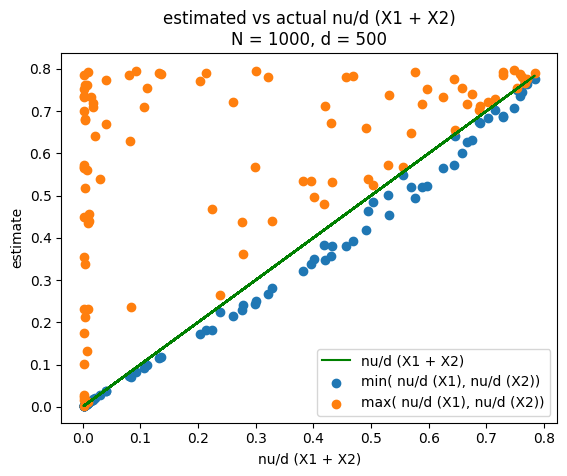

In [16]:
this_title = "estimated vs actual nu/d (X1 + X2)\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(nu_over_d_X1plusX2_vals, nu_over_d_X1plusX2_vals, color="green", label="nu/d (X1 + X2)")
plt.scatter(nu_over_d_X1plusX2_vals, min_nu_over_d_X1_nu_over_d_X2_vals, label="min( nu/d (X1), nu/d (X2))")
plt.scatter(nu_over_d_X1plusX2_vals, max_nu_over_d_X1_nu_over_d_X2_vals, label="max( nu/d (X1), nu/d (X2))")
#plt.scatter(nu_over_d_X1plusX2_vals, estimate_nu_over_d_X1plusX2_vals, label="estimate")
#plt.plot(nu_over_d_X1plusX2_vals, nu_over_d_X1plusX2_vals, color="red", label="actual")
plt.xlabel("nu/d (X1 + X2)")
plt.ylabel("estimate")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_X1_plus_X2_min_max.pdf', dpi=300, bbox_inches='tight')
plt.plot()

In [ ]:
this_title = "estimated vs actual nu/d (X1 + X2)\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(nu_over_d_X1plusX2_vals,nu_over_d_X1plusX2_vals, color="green", label="actual")
plt.scatter(nu_over_d_X1plusX2_vals, estimate_nu_over_d_X1plusX2_vals, label="estimate")
plt.plot(nu_over_d_X1plusX2_vals,nu_over_d_X1plusX2_vals, color="green", label="actual")
plt.xlabel("actual nu/d")
plt.ylabel("estimate nu/d")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_X1_plus_X2.pdf', dpi=300, bbox_inches='tight')
plt.plot()

# Addition experiment Two
## create two data manifolds X1, X2, each of dimension N * d
## each of these can be either Pareto, Uniform or Cauchy - either specified or chosen randomly
## calculate PP(Xi) and actual alpha_Xi
## define X12 = X1 + X2
## calculate PP(X12) and actual alpha_X12

In [16]:
num_iterations = 100

min_alpha = 0.1
max_alpha = 4.0
scale_factor = max_alpha - min_alpha

this_N = 1000
this_d = 500

alpha_X1_vals = np.zeros(num_iterations)
alpha_X2_vals = np.zeros(num_iterations)
actual_alpha_X1_vals = np.zeros(num_iterations)
actual_alpha_X2_vals = np.zeros(num_iterations)
actual_alpha_X1plusX2_vals = np.zeros(num_iterations)
estimate_alpha_X1plusX2_vals = np.zeros(num_iterations)
pp_dim_X1_vals = np.zeros(num_iterations)
pp_dim_X2_vals = np.zeros(num_iterations)
pp_dim_X1plusX2_vals = np.zeros(num_iterations)
nu_over_d_X1_vals = np.zeros(num_iterations)
nu_over_d_X2_vals = np.zeros(num_iterations)
nu_over_d_X1plusX2_vals = np.zeros(num_iterations)
estimate_nu_over_d_X1plusX2_vals = np.zeros(num_iterations)

max_nu_over_d_X1_nu_over_d_X2_vals = np.zeros(num_iterations)
min_nu_over_d_X1_nu_over_d_X2_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    this_alpha_X1 = min_alpha + scale_factor * np.random.uniform(0,1)
    this_alpha_X2 = min_alpha + scale_factor * np.random.uniform(0,1)

    results_dict = pp.addition_experiment_two(this_N, this_d, this_alpha_X1, this_alpha_X2, verbose=False)

    actual_alpha_X1 = results_dict["actual_alpha_X1"]
    actual_alpha_X2 = results_dict["actual_alpha_X2"]
    actual_alpha_X1plusX2 = results_dict["actual_alpha_X1plusX2"]
    pp_dim_X1 = results_dict["pp_dim_X1"] 
    pp_dim_X2 = results_dict["pp_dim_X2"]
    pp_dim_X1plusX2 = results_dict["pp_dim_X1plusX2"] 
    nu_over_d_X1 = results_dict["nu_over_d_X1"]
    nu_over_d_X2 = results_dict["nu_over_d_X2"] 
    nu_over_d_X1plusX2 = results_dict["nu_over_d_X1plusX2"] 
    
    alpha_X1_vals[i] = this_alpha_X1
    alpha_X2_vals[i] = this_alpha_X2
    actual_alpha_X1_vals[i] = actual_alpha_X1
    actual_alpha_X2_vals[i] = actual_alpha_X2
    actual_alpha_X1plusX2_vals[i] = actual_alpha_X1plusX2
    estimate_alpha_X1plusX2 = min(actual_alpha_X1, actual_alpha_X2)
    estimate_alpha_X1plusX2_vals[i] = estimate_alpha_X1plusX2
    pp_dim_X1_vals[i] = pp_dim_X1
    pp_dim_X2_vals[i] = pp_dim_X2
    pp_dim_X1plusX2_vals[i] = pp_dim_X1plusX2
    nu_over_d_X1_vals[i] = nu_over_d_X1
    nu_over_d_X2_vals[i] = nu_over_d_X2
    nu_over_d_X1plusX2_vals[i] = nu_over_d_X1plusX2
    estimate_nu_over_d_X1plusX2 = min(nu_over_d_X1, nu_over_d_X2)
    estimate_nu_over_d_X1plusX2_vals[i] = estimate_nu_over_d_X1plusX2

    max_nu_over_d_X1_nu_over_d_X2 = max(nu_over_d_X1, nu_over_d_X2)
    max_nu_over_d_X1_nu_over_d_X2_vals[i] = max_nu_over_d_X1_nu_over_d_X2
    min_nu_over_d_X1_nu_over_d_X2 = min(nu_over_d_X1, nu_over_d_X2)
    min_nu_over_d_X1_nu_over_d_X2_vals[i] = min_nu_over_d_X1_nu_over_d_X2

    
    print(i, actual_alpha_X1, actual_alpha_X2, actual_alpha_X1plusX2, estimate_alpha_X1plusX2)
    print(i, nu_over_d_X1, nu_over_d_X2, nu_over_d_X1plusX2, estimate_nu_over_d_X1plusX2)

0 0.0 0.0 0.0 0.0
0 0.6800469063955868 0.79921447615511 0.8129672597246927 0.6800469063955868
1 0.0 0.0 0.0 0.0
1 0.07825931172750682 0.14747430015076968 0.12477044627281281 0.07825931172750682
2 0.0 0.0 0.0 0.0
2 0.005716825645580991 0.7723610042200715 0.0059063152638416435 0.005716825645580991
3 0.0 0.0 0.0 0.0
3 0.6801497344584264 0.6566008129790536 0.76878189106882 0.6566008129790536
4 0.0 0.0 0.0 0.0
4 0.003911420190181119 0.799559280809458 0.00426551799033405 0.003911420190181119
5 0.0 0.0 0.0 0.0
5 0.017855109730214317 0.017422423304929744 0.030966116761518597 0.017422423304929744
6 0.0 0.0 0.0 0.0
6 0.6721638525725623 0.05003605492474638 0.05270143326453733 0.05003605492474638
7 0.0 0.0 0.0 0.0
7 0.022331365247408072 0.6187053118620419 0.029236807629358857 0.022331365247408072
8 0.0 0.0 0.0 0.0
8 0.11640311761955491 0.8070907343420013 0.16878377455558585 0.11640311761955491
9 0.0 0.0 0.0 0.0
9 0.6684668231120645 0.8202622807363545 0.8291717428502954 0.6684668231120645
10 0.0 0.

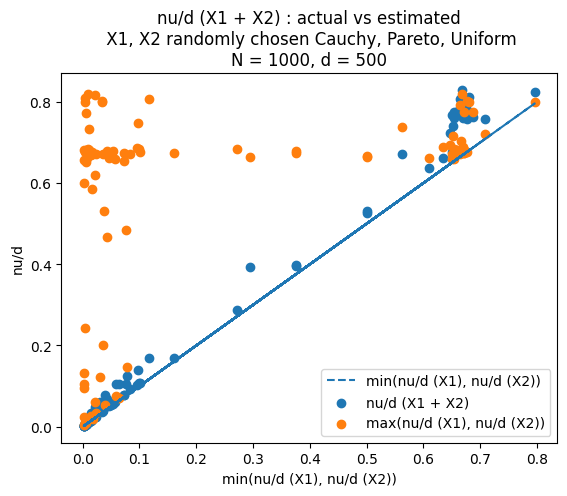

In [17]:
this_title = "nu/d (X1 + X2) : actual vs estimated\n X1, X2 randomly chosen Cauchy, Pareto, Uniform\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)

plt.plot(min_nu_over_d_X1_nu_over_d_X2_vals, min_nu_over_d_X1_nu_over_d_X2_vals, linestyle = "--", label = "min(nu/d (X1), nu/d (X2))")
plt.scatter(min_nu_over_d_X1_nu_over_d_X2_vals, nu_over_d_X1plusX2_vals, label = "nu/d (X1 + X2)")
plt.scatter(min_nu_over_d_X1_nu_over_d_X2_vals, max_nu_over_d_X1_nu_over_d_X2_vals, label = "max(nu/d (X1), nu/d (X2))")
plt.xlabel("min(nu/d (X1), nu/d (X2))")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_X1_plus_X2_two.pdf', dpi=300, bbox_inches='tight')
plt.show()